# 01 - Exploratory Data Analysis

## Objetivo
Inspeccionar la calidad y estructura del dataset.

1. Entender la granularidad y relación entre tablas.
2. Evaluar calidad de datos: nulos, duplicados, cobertura de joins y consistencia temporal.


In [21]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import (
    load_all_datasets,
    build_inventory_report,
    build_key_quality_report,
    build_item_level_base,
    top_n_products,
    top_n_categories,
    pain_point_summary,
    worst_categories_by_experience,
)

print(PROJECT_ROOT)

D:\Users\dhcertug\OneDrive - Crystal S.A.S\Escritorio\commercial-analytics-ai-challenge


In [7]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
geolocation = bundle.geolocation.copy()
order_items = bundle.order_items.copy()
order_payments = bundle.order_payments.copy()
order_reviews = bundle.order_reviews.copy()
orders = bundle.orders.copy()
products = bundle.products.copy()
translation = bundle.product_category_translation.copy()
sellers = bundle.sellers.copy()

In [ ]:
## Inventario general del dataset
def table_profile(df: pd.DataFrame, name: str) -> dict:
    return {
        "table": name,
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "duplicates": int(df.duplicated().sum()),
        "null_cells": int(df.isna().sum().sum()),
        "null_pct": round(float(df.isna().mean().mean() * 100), 2),
    }

inventory = pd.DataFrame([
    table_profile(customers, "customers"),
    table_profile(geolocation, "geolocation"),
    table_profile(order_items, "order_items"),
    table_profile(order_payments, "order_payments"),
    table_profile(order_reviews, "order_reviews"),
    table_profile(orders, "orders"),
    table_profile(products, "products"),
    table_profile(translation, "product_category_translation"),
    table_profile(sellers, "sellers"),
]).sort_values(["rows", "cols"], ascending=False).reset_index(drop=True)

inventory

,table,rows,cols,duplicates,null_cells,null_pct
0,geolocation,1000163,5,261831,0,0.00
1,order_items,112650,7,0,0,0.00
2,order_payments,103886,5,0,0,0.00
3,orders,99441,8,0,4908,0.62
4,customers,99441,5,0,0,0.00
5,order_reviews,99224,7,0,145903,21.01
6,products,32951,9,0,2448,0.83
7,sellers,3095,4,0,0,0.00
8,product_category_translation,71,2,0,0,0.00


In [ ]:
## Vista de cada tabla
tables = {
    "customers": customers,
    "geolocation": geolocation,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "orders": orders,
    "products": products,
    "product_category_translation": translation,
    "sellers": sellers,
}

for name, df in tables.items():
    print("=" * 100)
    print(f"{name.upper()} | shape={df.shape}")
    display(df.head(3))
    print()

CUSTOMERS | shape=(99441, 5)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



GEOLOCATION | shape=(1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP



ORDER_ITEMS | shape=(112650, 7)


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.00,250.00,1.00,154.00,18.00,9.00,15.00



PRODUCT_CATEGORY_TRANSLATION | shape=(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



SELLERS | shape=(3095, 4)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


## 1. Nulos por columna

- qué columnas están incompletas(?)
- y si esos nulos afectan análisis de negocio o solo metadata secundaria.

In [13]:
null_report = []

for name, df in tables.items():
    tmp = pd.DataFrame({
        "table": name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "nulls": df.isna().sum().values,
        "null_pct": (df.isna().mean().values * 100).round(2),
        "nunique": [df[c].nunique(dropna=True) for c in df.columns],
    })
    null_report.append(tmp)

null_report = pd.concat(null_report, ignore_index=True)
null_report.sort_values(["null_pct", "nulls"], ascending=False).head(50)

,table,column,dtype,nulls,null_pct,nunique
25,order_reviews,review_comment_title,object,87656,88.34,4527
26,order_reviews,review_comment_message,object,58247,58.70,36159
35,orders,order_delivered_customer_date,datetime64[ns],2965,2.98,95664
38,products,product_category_name,object,610,1.85,73
39,products,product_name_lenght,float64,610,1.85,66
40,products,product_description_lenght,float64,610,1.85,2960
41,products,product_photos_qty,float64,610,1.85,19
34,orders,order_delivered_carrier_date,datetime64[ns],1783,1.79,81018
33,orders,order_approved_at,datetime64[ns],160,0.16,90733
42,products,product_weight_g,float64,2,0.01,2204


In [14]:
## 4. Validación campos y cardinalidad entre trablas
key_checks = pd.DataFrame([
    {"table": "customers", "column": "customer_id", "rows": len(customers), "distinct": customers["customer_id"].nunique(), "nulls": customers["customer_id"].isna().sum(), "is_unique": customers["customer_id"].is_unique},
    {"table": "customers", "column": "customer_unique_id", "rows": len(customers), "distinct": customers["customer_unique_id"].nunique(), "nulls": customers["customer_unique_id"].isna().sum(), "is_unique": customers["customer_unique_id"].is_unique},
    {"table": "orders", "column": "order_id", "rows": len(orders), "distinct": orders["order_id"].nunique(), "nulls": orders["order_id"].isna().sum(), "is_unique": orders["order_id"].is_unique},
    {"table": "orders", "column": "customer_id", "rows": len(orders), "distinct": orders["customer_id"].nunique(), "nulls": orders["customer_id"].isna().sum(), "is_unique": orders["customer_id"].is_unique},
    {"table": "order_items", "column": "order_id", "rows": len(order_items), "distinct": order_items["order_id"].nunique(), "nulls": order_items["order_id"].isna().sum(), "is_unique": order_items["order_id"].is_unique},
    {"table": "order_items", "column": "product_id", "rows": len(order_items), "distinct": order_items["product_id"].nunique(), "nulls": order_items["product_id"].isna().sum(), "is_unique": order_items["product_id"].is_unique},
    {"table": "order_reviews", "column": "review_id", "rows": len(order_reviews), "distinct": order_reviews["review_id"].nunique(), "nulls": order_reviews["review_id"].isna().sum(), "is_unique": order_reviews["review_id"].is_unique},
    {"table": "order_reviews", "column": "order_id", "rows": len(order_reviews), "distinct": order_reviews["order_id"].nunique(), "nulls": order_reviews["order_id"].isna().sum(), "is_unique": order_reviews["order_id"].is_unique},
    {"table": "products", "column": "product_id", "rows": len(products), "distinct": products["product_id"].nunique(), "nulls": products["product_id"].isna().sum(), "is_unique": products["product_id"].is_unique},
    {"table": "sellers", "column": "seller_id", "rows": len(sellers), "distinct": sellers["seller_id"].nunique(), "nulls": sellers["seller_id"].isna().sum(), "is_unique": sellers["seller_id"].is_unique},
])

key_checks

,table,column,rows,distinct,nulls,is_unique
0,customers,customer_id,99441,99441,0,True
1,customers,customer_unique_id,99441,96096,0,False
2,orders,order_id,99441,99441,0,True
3,orders,customer_id,99441,99441,0,True
4,order_items,order_id,112650,98666,0,False
5,order_items,product_id,112650,32951,0,False
6,order_reviews,review_id,99224,98410,0,False
7,order_reviews,order_id,99224,98673,0,False
8,products,product_id,32951,32951,0,True
9,sellers,seller_id,3095,3095,0,True


## 2. Cliente transaccional vs cliente real


In [15]:
customer_repeat_behavior = (
    customers.groupby("customer_unique_id", as_index=False)
    .agg(
        n_customer_ids=("customer_id", "nunique"),
        n_states=("customer_state", "nunique"),
        n_cities=("customer_city", "nunique"),
    )
    .sort_values("n_customer_ids", ascending=False)
    .reset_index(drop=True)
)

customer_repeat_behavior.head(20)

,customer_unique_id,n_customer_ids,n_states,n_cities
0,8d50f5eadf50201ccdcedfb9e2ac8455,17,1,1
1,3e43e6105506432c953e165fb2acf44c,9,1,1
2,1b6c7548a2a1f9037c1fd3ddfed95f33,7,1,1
3,6469f99c1f9dfae7733b25662e7f1782,7,1,1
4,ca77025e7201e3b30c44b472ff346268,7,1,1
5,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,1,1
6,12f5d6e1cbf93dafd9dcc19095df0b3d,6,1,1
7,63cfc61cee11cbe306bff5857d00bfe4,6,1,1
8,dc813062e0fc23409cd255f7f53c7074,6,1,1
9,de34b16117594161a6a89c50b289d35a,6,1,1


In [16]:
customer_repeat_behavior["n_customer_ids"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count   96,096.00
mean         1.03
std          0.21
min          1.00
50%          1.00
75%          1.00
90%          1.00
95%          1.00
99%          2.00
max         17.00
Name: n_customer_ids, dtype: float64

In [17]:
### Cobertura entre tablas 
def join_coverage(left_df, right_df, left_on, right_on=None, how="left", name="join"):
    right_on = right_on or left_on
    tmp = left_df.merge(
        right_df[[right_on]].drop_duplicates(),
        left_on=left_on,
        right_on=right_on,
        how=how,
        indicator=True
    )
    return pd.DataFrame({
        "join_name": [name],
        "left_rows": [len(left_df)],
        "matched_rows": [(tmp["_merge"] != "left_only").sum()],
        "unmatched_rows": [(tmp["_merge"] == "left_only").sum()],
        "match_rate_pct": [round(((tmp["_merge"] != "left_only").mean() * 100), 2)],
    })

coverage_report = pd.concat([
    join_coverage(orders, customers, "customer_id", name="orders -> customers"),
    join_coverage(order_items, orders, "order_id", name="order_items -> orders"),
    join_coverage(order_items, products, "product_id", name="order_items -> products"),
    join_coverage(order_items, sellers, "seller_id", name="order_items -> sellers"),
    join_coverage(order_reviews, orders, "order_id", name="order_reviews -> orders"),
], ignore_index=True)

coverage_report

,join_name,left_rows,matched_rows,unmatched_rows,match_rate_pct
0,orders -> customers,99441,99441,0,100.00
1,order_items -> orders,112650,112650,0,100.00
2,order_items -> products,112650,112650,0,100.00
3,order_items -> sellers,112650,112650,0,100.00
4,order_reviews -> orders,99224,99224,0,100.00


## 3. Estructura transaccional de pedidos

- cuántos ítems tiene un pedido,
- cuántos productos distintos puede tener,
- cuántos sellers puede involucrar un pedido.

In [18]:
order_structure = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        n_items=("order_item_id", "count"),
        n_distinct_products=("product_id", "nunique"),
        n_distinct_sellers=("seller_id", "nunique"),
        item_price_total=("price", "sum"),
        freight_total=("freight_value", "sum"),
    )
)

order_structure.head()

,order_id,n_items,n_distinct_products,n_distinct_sellers,item_price_total,freight_total
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14


In [19]:
order_structure[["n_items", "n_distinct_products", "n_distinct_sellers", "item_price_total", "freight_total"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_items,"98,666.00",1.14,0.54,1.00,1.00,1.00,1.00,2.00,3.00,21.00
n_distinct_products,"98,666.00",1.04,0.23,1.00,1.00,1.00,1.00,1.00,2.00,8.00
n_distinct_sellers,"98,666.00",1.01,0.12,1.00,1.00,1.00,1.00,1.00,2.00,5.00
item_price_total,"98,666.00",137.75,210.65,0.85,86.90,149.90,269.90,399.90,998.90,"13,440.00"
freight_total,"98,666.00",22.82,21.65,0.00,17.17,24.04,39.50,54.96,104.98,"1,794.96"


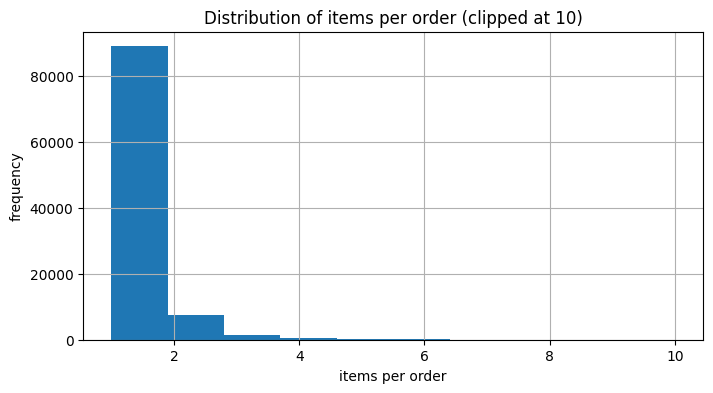

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
order_structure["n_items"].clip(upper=10).hist(ax=ax, bins=10)
ax.set_title("Distribution of items per order (clipped at 10)")
ax.set_xlabel("items per order")
ax.set_ylabel("frequency")
plt.show()

## 4. Estado de pedidos 

- distribución por `order_status`,
- rango temporal del dataset,
- comportamiento por mes.

In [23]:
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

order_status_dist = (
    orders["order_status"]
    .value_counts(dropna=False)
    .rename_axis("order_status")
    .reset_index(name="orders")
)

order_status_dist["pct"] = order_status_dist["orders"] / len(orders) * 100
order_status_dist

,order_status,orders,pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [24]:
monthly_orders = (
    orders.groupby("purchase_month", as_index=False)
    .agg(n_orders=("order_id", "nunique"))
    .sort_values("purchase_month")
)

monthly_orders.tail(12)

,purchase_month,n_orders
13,2017-11,7544
14,2017-12,5673
15,2018-01,7269
16,2018-02,6728
17,2018-03,7211
18,2018-04,6939
19,2018-05,6873
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512


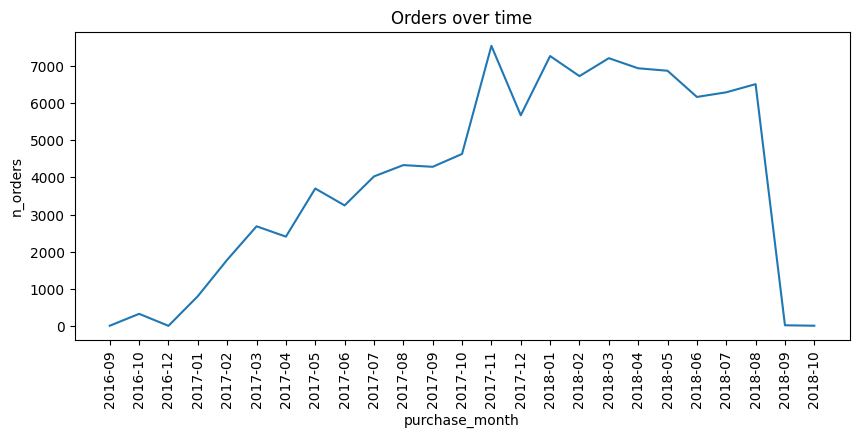

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_orders["purchase_month"], monthly_orders["n_orders"])
ax.set_title("Orders over time")
ax.set_xlabel("purchase_month")
ax.set_ylabel("n_orders")
ax.tick_params(axis="x", rotation=90)
plt.show()

## 5. Flujo logístico y retrasos

Primero medimos:
- cobertura de timestamps,
- y retraso real contra fecha estimada.

In [26]:
delivery_nulls = (
    orders[[
        "order_status",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]]
    .isna()
    .groupby(orders["order_status"])
    .mean()
    .mul(100)
    .round(2)
)

delivery_nulls

,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
order_status,,,,,
approved,0.00,0.00,100.00,100.00,0.00
canceled,0.00,22.56,88.00,99.04,0.00
created,0.00,100.00,100.00,100.00,0.00
delivered,0.00,0.01,0.00,0.01,0.00
invoiced,0.00,0.00,100.00,100.00,0.00
processing,0.00,0.00,100.00,100.00,0.00
shipped,0.00,0.00,0.00,100.00,0.00
unavailable,0.00,0.00,100.00,100.00,0.00


In [27]:
delivered_orders = orders.loc[orders["order_status"] == "delivered"].copy()

delivered_orders["delivery_delay_days"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_estimated_delivery_date"]
).dt.days

delivered_orders["is_late_delivery"] = delivered_orders["delivery_delay_days"] > 0
delivered_orders["days_to_approve"] = (
    delivered_orders["order_approved_at"] - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivered_orders["days_to_deliver"] = (
    delivered_orders["order_delivered_customer_date"] - delivered_orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

delivered_orders[["delivery_delay_days", "days_to_approve", "days_to_deliver"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
delivery_delay_days,"96,470.00",-11.88,10.18,-147.00,-12.00,-7.00,-2.00,3.00,18.00,188.00
days_to_approve,"96,464.00",0.43,0.86,0.00,0.01,0.60,1.44,2.01,3.74,30.89
days_to_deliver,"96,470.00",12.56,9.55,0.53,10.22,15.72,23.10,29.27,46.05,209.63


In [28]:
delivered_orders["is_late_delivery"].mean()

np.float64(0.0677252845208234)

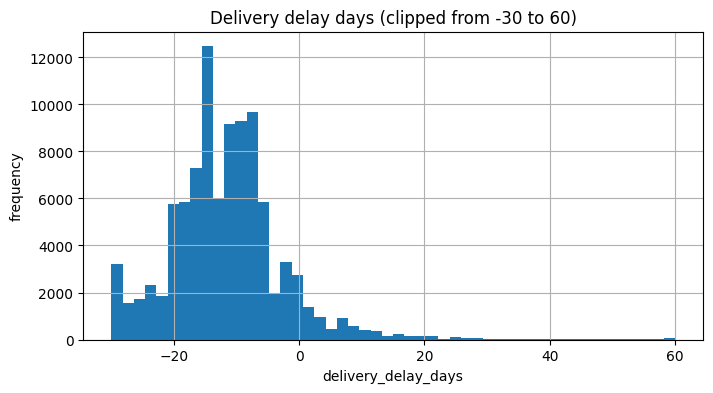

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
delivered_orders["delivery_delay_days"].clip(lower=-30, upper=60).hist(ax=ax, bins=50)
ax.set_title("Delivery delay days (clipped from -30 to 60)")
ax.set_xlabel("delivery_delay_days")
ax.set_ylabel("frequency")
plt.show()

## 6. Reviews: cobertura, score y comentarios

- existencia de review,
- score numérico,
- comentario textual.

Observación:  Los nulos en reviews no siempre significan ausencia de experiencia; muchas veces solo significan ausencia de comentario.

In [30]:
review_coverage = pd.DataFrame({
    "metric": [
        "orders_with_review",
        "orders_without_review",
        "review_score_nulls",
        "review_comment_title_nulls",
        "review_comment_message_nulls",
    ],
    "value": [
        orders["order_id"].isin(order_reviews["order_id"]).sum(),
        (~orders["order_id"].isin(order_reviews["order_id"])).sum(),
        order_reviews["review_score"].isna().sum(),
        order_reviews["review_comment_title"].isna().sum(),
        order_reviews["review_comment_message"].isna().sum(),
    ],
})

review_coverage

,metric,value
0,orders_with_review,98673
1,orders_without_review,768
2,review_score_nulls,0
3,review_comment_title_nulls,87656
4,review_comment_message_nulls,58247


In [31]:
review_score_dist = (
    order_reviews["review_score"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="n_reviews")
)

review_score_dist["pct"] = review_score_dist["n_reviews"] / len(order_reviews) * 100
review_score_dist

,review_score,n_reviews,pct
0,1,11424,11.51
1,2,3151,3.18
2,3,8179,8.24
3,4,19142,19.29
4,5,57328,57.78


In [32]:
low_score_comments = order_reviews.loc[order_reviews["review_score"] <= 2].copy()

comment_availability = pd.DataFrame({
    "group": ["all_reviews", "low_score_reviews"],
    "comment_message_non_null_pct": [
        round(order_reviews["review_comment_message"].notna().mean() * 100, 2),
        round(low_score_comments["review_comment_message"].notna().mean() * 100, 2),
    ],
    "comment_title_non_null_pct": [
        round(order_reviews["review_comment_title"].notna().mean() * 100, 2),
        round(low_score_comments["review_comment_title"].notna().mean() * 100, 2),
    ]
})

comment_availability

,group,comment_message_non_null_pct,comment_title_non_null_pct
0,all_reviews,41.30,11.66
1,low_score_reviews,74.72,16.13


## 7. Consistencia entre items y pagos

Antes validamos si:
- `payment_value` se parece a `price + freight`,
- o si hay diferencias relevantes por cupones, redondeos u otras mecánicas.

In [33]:
payments_by_order = (
    order_payments.groupby("order_id", as_index=False)
    .agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_type_nunique=("payment_type", "nunique"),
    )
)

financials = (
    order_structure.merge(payments_by_order, on="order_id", how="left")
    .merge(orders[["order_id", "order_status"]], on="order_id", how="left")
)

financials["items_plus_freight"] = financials["item_price_total"] + financials["freight_total"]
financials["payment_gap"] = financials["payment_value_total"] - financials["items_plus_freight"]

financials.head()

,order_id,n_items,n_distinct_products,n_distinct_sellers,item_price_total,freight_total,payment_value_total,payment_installments_max,payment_type_nunique,order_status,items_plus_freight,payment_gap
0,00010242fe8c5a6d1ba2dd792cb16214,1,1,1,58.90,13.29,72.19,2.00,1.00,delivered,72.19,0.00
1,00018f77f2f0320c557190d7a144bdd3,1,1,1,239.90,19.93,259.83,3.00,1.00,delivered,259.83,0.00
2,000229ec398224ef6ca0657da4fc703e,1,1,1,199.00,17.87,216.87,5.00,1.00,delivered,216.87,0.00
3,00024acbcdf0a6daa1e931b038114c75,1,1,1,12.99,12.79,25.78,2.00,1.00,delivered,25.78,0.00
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,1,1,199.90,18.14,218.04,3.00,1.00,delivered,218.04,-0.00


In [34]:
financials[["item_price_total", "freight_total", "items_plus_freight", "payment_value_total", "payment_gap"]].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).T

,count,mean,std,min,50%,75%,90%,95%,99%,max
item_price_total,"98,666.00",137.75,210.65,0.85,86.90,149.90,269.90,399.90,998.90,"13,440.00"
freight_total,"98,666.00",22.82,21.65,0.00,17.17,24.04,39.50,54.96,104.98,"1,794.96"
items_plus_freight,"98,666.00",160.58,220.47,9.59,105.29,176.87,307.69,450.53,"1,063.32","13,664.08"
payment_value_total,"98,665.00",160.61,220.48,9.59,105.29,176.88,307.71,450.53,"1,063.33","13,664.08"
payment_gap,"98,665.00",0.03,1.13,-51.62,0.00,0.00,0.00,0.00,0.00,182.81


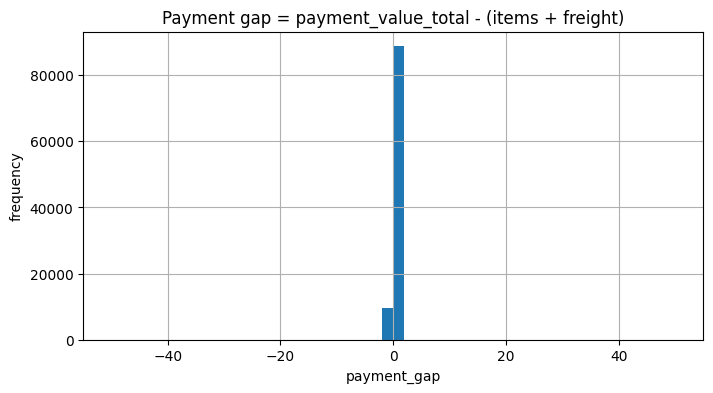

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
financials["payment_gap"].fillna(0).clip(lower=-50, upper=50).hist(ax=ax, bins=50)
ax.set_title("Payment gap = payment_value_total - (items + freight)")
ax.set_xlabel("payment_gap")
ax.set_ylabel("frequency")
plt.show()

## 8. Productos y categorías

Antes de reportar categorías más vendidas, debemos validar:
- cobertura de `product_category_name`,
- cobertura de traducción al inglés,
- y completitud general de metadata del producto.

In [36]:
products_quality = pd.DataFrame({
    "metric": [
        "products_rows",
        "product_id_unique",
        "category_null_pct",
        "name_length_null_pct",
        "description_length_null_pct",
        "photos_qty_null_pct",
    ],
    "value": [
        len(products),
        products["product_id"].is_unique,
        round(products["product_category_name"].isna().mean() * 100, 2),
        round(products["product_name_lenght"].isna().mean() * 100, 2),
        round(products["product_description_lenght"].isna().mean() * 100, 2),
        round(products["product_photos_qty"].isna().mean() * 100, 2),
    ]
})

products_quality

,metric,value
0,products_rows,32951
1,product_id_unique,True
2,category_null_pct,1.85
3,name_length_null_pct,1.85
4,description_length_null_pct,1.85
5,photos_qty_null_pct,1.85


In [37]:
category_translation_check = (
    products[["product_id", "product_category_name"]]
    .merge(translation, on="product_category_name", how="left")
)

pd.DataFrame({
    "metric": [
        "products_with_category",
        "products_without_category",
        "products_with_translation",
        "products_without_translation",
    ],
    "value": [
        category_translation_check["product_category_name"].notna().sum(),
        category_translation_check["product_category_name"].isna().sum(),
        category_translation_check["product_category_name_english"].notna().sum(),
        category_translation_check["product_category_name_english"].isna().sum(),
    ]
})

,metric,value
0,products_with_category,32341
1,products_without_category,610
2,products_with_translation,32328
3,products_without_translation,623


In [38]:
top_raw_categories = (
    products["product_category_name"]
    .fillna("unknown")
    .value_counts()
    .head(20)
    .rename_axis("product_category_name")
    .reset_index(name="n_products")
)

top_raw_categories

,product_category_name,n_products
0,cama_mesa_banho,3029
1,esporte_lazer,2867
2,moveis_decoracao,2657
3,beleza_saude,2444
4,utilidades_domesticas,2335
5,automotivo,1900
6,informatica_acessorios,1639
7,brinquedos,1411
8,relogios_presentes,1329
9,telefonia,1134


## 13. Geolocalización: calidad del dato

Vamos a medir:
- duplicados exactos,
- multiplicidad por zip prefix,
- y una estrategia inicial de deduplicación.

In [39]:
geo_summary = pd.DataFrame({
    "metric": [
        "rows",
        "exact_duplicate_rows",
        "unique_zip_prefix",
        "unique_city_state_pairs",
    ],
    "value": [
        len(geolocation),
        geolocation.duplicated().sum(),
        geolocation["geolocation_zip_code_prefix"].nunique(),
        geolocation[["geolocation_city", "geolocation_state"]].drop_duplicates().shape[0],
    ]
})

geo_summary

,metric,value
0,rows,1000163
1,exact_duplicate_rows,261831
2,unique_zip_prefix,19015
3,unique_city_state_pairs,8463


In [40]:
zip_prefix_multiplicity = (
    geolocation.groupby("geolocation_zip_code_prefix")
    .size()
    .rename("rows_per_zip_prefix")
    .reset_index()
)

zip_prefix_multiplicity["rows_per_zip_prefix"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
)

count   19,015.00
mean        52.60
std         72.06
min          1.00
50%         29.00
75%         66.50
90%        124.00
95%        180.00
99%        353.00
max      1,146.00
Name: rows_per_zip_prefix, dtype: float64

In [41]:
geolocation_dedup = (
    geolocation.groupby("geolocation_zip_code_prefix", as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean"),
        geolocation_city=("geolocation_city", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
        geolocation_state=("geolocation_state", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
        n_rows=("geolocation_zip_code_prefix", "size"),
    )
)

geolocation_dedup.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,n_rows
0,1001,-23.55,-46.63,sao paulo,SP,26
1,1002,-23.55,-46.63,sao paulo,SP,13
2,1003,-23.55,-46.64,sao paulo,SP,17
3,1004,-23.55,-46.63,sao paulo,SP,22
4,1005,-23.55,-46.64,sao paulo,SP,25


In [ ]:
## Base exploratoria a nivel item

# - producto,
# - categoría,
# - pedido,
# - review,
# - cliente,
# - seller,
# - pagos,
# - logística.

reviews_agg = (
    order_reviews.sort_values(["order_id", "review_creation_date"], ascending=[True, False], na_position="last")
    .groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean"),
        review_comment_title=("review_comment_title", "first"),
        review_comment_message=("review_comment_message", "first"),
    )
)

payments_agg = (
    order_payments.groupby("order_id", as_index=False)
    .agg(
        payment_value_total=("payment_value", "sum"),
        payment_installments_max=("payment_installments", "max"),
        payment_type_nunique=("payment_type", "nunique"),
    )
)

item_base = (
    order_items
    .merge(orders, on="order_id", how="inner", validate="many_to_one")
    .merge(products, on="product_id", how="left", validate="many_to_one")
    .merge(translation, on="product_category_name", how="left", validate="many_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
    .merge(sellers, on="seller_id", how="left", validate="many_to_one")
    .merge(reviews_agg, on="order_id", how="left", validate="many_to_one")
    .merge(payments_agg, on="order_id", how="left", validate="many_to_one")
)

item_base["product_category"] = item_base["product_category_name_english"].fillna(item_base["product_category_name"]).fillna("unknown")
item_base["quantity"] = 1
item_base["item_revenue"] = item_base["price"].fillna(0)
item_base["gross_revenue"] = item_base["price"].fillna(0) + item_base["freight_value"].fillna(0)
item_base["delivery_delay_days"] = (item_base["order_delivered_customer_date"] - item_base["order_estimated_delivery_date"]).dt.days
item_base["is_late_delivery"] = item_base["delivery_delay_days"] > 0
item_base["is_bad_review"] = item_base["review_score"].fillna(5) <= 2
item_base["is_neutral_or_worse_review"] = item_base["review_score"].fillna(5) <= 3

item_base.shape


(112650, 45)

In [43]:
item_base[[
    "order_id",
    "order_item_id",
    "product_id",
    "product_category",
    "order_status",
    "price",
    "freight_value",
    "item_revenue",
    "gross_revenue",
    "review_score",
    "delivery_delay_days",
    "is_late_delivery",
    "is_bad_review",
]].head(10)

,order_id,order_item_id,product_id,product_category,order_status,price,freight_value,item_revenue,gross_revenue,review_score,delivery_delay_days,is_late_delivery,is_bad_review
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,delivered,58.90,13.29,58.90,72.19,5.00,-9.00,False,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,pet_shop,delivered,239.90,19.93,239.90,259.83,4.00,-3.00,False,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,delivered,199.00,17.87,199.00,216.87,5.00,-14.00,False,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,perfumery,delivered,12.99,12.79,12.99,25.78,4.00,-6.00,False,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,garden_tools,delivered,199.90,18.14,199.90,218.04,5.00,-16.00,False,False
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,housewares,delivered,21.90,12.69,21.90,34.59,4.00,-15.00,False,False
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,telephony,delivered,19.90,11.85,19.90,31.75,4.00,-17.00,False,False
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,garden_tools,delivered,810.00,70.75,810.00,880.75,5.00,-16.00,False,False
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,health_beauty,delivered,145.95,11.65,145.95,157.60,1.00,0.00,False,True
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,books_technical,delivered,53.99,11.40,53.99,65.39,4.00,-19.00,False,False


In [44]:
delivered_item_base = item_base.loc[item_base["order_status"] == "delivered"].copy()

delay_vs_review = pd.crosstab(
    delivered_item_base["is_late_delivery"],
    delivered_item_base["is_bad_review"],
    normalize="index"
).rename(columns={False: "not_bad_review", True: "bad_review"})

delay_vs_review

is_bad_review,not_bad_review,bad_review
is_late_delivery,,
False,0.89,0.11
True,0.39,0.61


In [45]:
delay_review_summary = (
    delivered_item_base.groupby("is_late_delivery", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        neutral_or_worse_rate=("is_neutral_or_worse_review", "mean"),
    )
)

delay_review_summary

,is_late_delivery,n_items,avg_review_score,bad_review_rate,neutral_or_worse_rate
0,False,102933,4.21,0.11,0.20
1,True,7264,2.26,0.61,0.72


In [ ]:
## Categorías con más volumen, más ingresos y peor experiencia
category_diagnostics = (
    delivered_item_base.groupby("product_category", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        n_products=("product_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
    )
)

category_diagnostics.sort_values("n_items", ascending=False).head(15)

,product_category,n_items,n_orders,n_products,total_revenue,total_gross_revenue,avg_review_score,bad_review_rate,late_delivery_rate,avg_delay_days
7,bed_bath_table,10953,9272,2991,"1,023,434.76","1,225,209.26",3.92,0.18,0.07,-11.66
43,health_beauty,9465,8647,2397,"1,233,131.72","1,412,089.53",4.19,0.12,0.08,-11.97
67,sports_leisure,8431,7530,2822,"954,852.55","1,118,256.91",4.17,0.13,0.06,-12.01
39,furniture_decor,8160,6307,2593,"711,927.69","880,329.92",3.95,0.18,0.07,-12.40
15,computers_accessories,7644,6530,1600,"888,724.61","1,032,723.77",3.99,0.17,0.06,-12.42
49,housewares,6795,5743,2282,"615,628.69","758,392.25",4.11,0.14,0.05,-12.30
73,watches_gifts,5859,5495,1300,"1,166,176.98","1,264,333.12",4.07,0.15,0.07,-11.92
70,telephony,4430,4093,1112,"309,860.23","379,202.62",3.99,0.15,0.07,-11.38
42,garden_tools,4268,3448,725,"470,495.28","567,145.68",4.08,0.15,0.07,-11.98
5,auto,4140,3810,1853,"578,966.65","669,454.75",4.12,0.14,0.07,-11.44


In [47]:
category_diagnostics = (
    delivered_item_base.groupby("product_category", as_index=False)
    .agg(
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        n_products=("product_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        total_gross_revenue=("gross_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
    )
)

category_diagnostics.sort_values("n_items", ascending=False).head(15)

,product_category,n_items,n_orders,n_products,total_revenue,total_gross_revenue,avg_review_score,bad_review_rate,late_delivery_rate,avg_delay_days
7,bed_bath_table,10953,9272,2991,"1,023,434.76","1,225,209.26",3.92,0.18,0.07,-11.66
43,health_beauty,9465,8647,2397,"1,233,131.72","1,412,089.53",4.19,0.12,0.08,-11.97
67,sports_leisure,8431,7530,2822,"954,852.55","1,118,256.91",4.17,0.13,0.06,-12.01
39,furniture_decor,8160,6307,2593,"711,927.69","880,329.92",3.95,0.18,0.07,-12.40
15,computers_accessories,7644,6530,1600,"888,724.61","1,032,723.77",3.99,0.17,0.06,-12.42
49,housewares,6795,5743,2282,"615,628.69","758,392.25",4.11,0.14,0.05,-12.30
73,watches_gifts,5859,5495,1300,"1,166,176.98","1,264,333.12",4.07,0.15,0.07,-11.92
70,telephony,4430,4093,1112,"309,860.23","379,202.62",3.99,0.15,0.07,-11.38
42,garden_tools,4268,3448,725,"470,495.28","567,145.68",4.08,0.15,0.07,-11.98
5,auto,4140,3810,1853,"578,966.65","669,454.75",4.12,0.14,0.07,-11.44


In [48]:
## Productos frecuentes con peor experiencia

## Filtramos productos con un mínimo de órdenes para evitar ruido estadístico.

product_diagnostics = (
    delivered_item_base.groupby("product_id", as_index=False)
    .agg(
        product_category=("product_category", lambda s: s.mode().iloc[0] if not s.mode().empty else "unknown"),
        n_items=("quantity", "sum"),
        n_orders=("order_id", "nunique"),
        total_revenue=("item_revenue", "sum"),
        avg_review_score=("review_score", "mean"),
        bad_review_rate=("is_bad_review", "mean"),
        late_delivery_rate=("is_late_delivery", "mean"),
        avg_delay_days=("delivery_delay_days", "mean"),
    )
)

product_diagnostics.query("n_orders >= 10").sort_values(
    ["bad_review_rate", "late_delivery_rate", "avg_review_score"],
    ascending=[False, False, True]
).head(30)

,product_id,product_category,n_items,n_orders,total_revenue,avg_review_score,bad_review_rate,late_delivery_rate,avg_delay_days
31825,fd0065af7f09af4b82a0ca8f3eed1852,auto,10,10,"19,999.90",1.20,0.90,0.90,8.70
25851,cd46a885543f0e169a49f1eb25c04e43,computers_accessories,30,28,"2,999.70",1.83,0.77,0.00,-24.60
22327,b1d207586fca400a2370d50a9ba1da98,unknown,47,42,"7,003.00",1.91,0.74,0.11,-7.83
13791,6d2fde7d12bb6ff367dbda120ba8828e,computers_accessories,18,12,395.50,2.06,0.72,0.00,-9.56
2940,16bf176650a888512655cc94f61860e3,watches_gifts,13,11,507.00,2.23,0.69,0.23,-6.92
22509,b36f3c918c91478c4559160022d3f14e,unknown,15,15,"2,250.00",1.79,0.67,0.53,0.47
2620,145028037adecb27b1a58cf9597676cc,office_furniture,14,10,"5,586.00",2.43,0.64,0.00,-12.29
1331,0a9bdadab17a9b0f258f64d11a0adf7b,furniture_decor,22,10,"1,829.56",2.36,0.64,0.00,-17.09
8649,43ee88561093499d9e571d4db5f20b79,furniture_decor,20,13,218.00,2.55,0.60,0.15,-9.50
16998,86ecc269de40ba13205e7beeee12f26f,telephony,12,12,355.88,2.67,0.58,0.25,-2.58
